# cice_basics class example

This notebook demonstrates a minimal workflow for `mawsons-chest` using the `cice_basics` class.

It is designed for direct daily CICE history files (`iceh.*.nc`) and optional daily NSIDC comparison.

In [1]:
import sys, os, pygmt, importlib
mod_path = '/home/581/da1339/AFIM/src/mawsons-chest/nilas'
sys.path.insert(0, mod_path)
from cice_netcdf_tools       import cice_basics
import numpy                 as np
import pandas                as pd
import xarray                as xr
import xesmf                 as xe
import matplotlib.pyplot     as plt
from pathlib                 import Path

## Initialise the toolbox

The defaults below follow the current Gadi-style directory structure used in your workflow. Override any path here if needed.

In [2]:
project   = "gv90"
user      = "da1339"
D_gdata   = Path(f"/g/data/{project}/{user}")
D_nsidc   = D_gdata / "SeaIce" / "NSIDC"
nsidc_ver = "V4"
D_runs    = D_gdata / "cice-dirs" / "runs"
run_name  = "free-slip-waves"
tb        = cice_basics(cice_history_dir      = D_runs / run_name / "history",
                        nsidc_daily_south_dir = D_nsidc / f"G02202_{nsidc_ver}" / "south" / "daily", 
                        nsidc_daily_north_dir = D_nsidc / f"G02202_{nsidc_ver}" / "north" / "daily",
                        nsidc_cell_area_south = D_nsidc / "NSIDC0771" / "NSIDC0771_CellArea_PS_S25km_v1.1.nc",
                        nsidc_cell_area_north = D_nsidc / "NSIDC0771" / "NSIDC0771_CellArea_PS_N25km_v1.1.nc",
                        output_dir            = D_gdata / "GRAPHICAL" / "mawsons-chest" / run_name,
                        animation_dir         = D_gdata / "GRAPHICAL" / "mawsons-chest" / run_name / "animations",
                        sic_threshold         = 0.15)

## Choose a CICE day

In [3]:
date_str = "1994-01-04"
ds       = tb.load_cice_day(date_str)
dt_str   = tb.cice_corrected_datestr(ds)
print("Requested file date:", date_str)
print("Corrected CICE date string:", dt_str)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


Requested file date: 1994-01-04
Corrected CICE date string: 1994-01-04


## Compute hemispheric sea-ice extent from CICE `aice`

In [4]:
ext = tb.compute_cice_ice_extent(ds)
print("SH SIE:", ext["south"], ext["units"])
print("NH SIE:", ext["north"], ext["units"])
print("Threshold:", ext["threshold"])

SH SIE: 5.989097388516 10^6 km^2
NH SIE: 13.325222076624 10^6 km^2
Threshold: 0.15


## Compute hemispheric SIA, SIV, and aggregate SIT from `hi` and `aice`

In [5]:
stats = tb.compute_cice_area_volume_thickness(ds)
print("SH SIA:", stats["south"]["SIA"], stats["SIA_units"])
print("SH SIV:", stats["south"]["SIV"], stats["SIV_units"])
print("SH SIT:", stats["south"]["SIT"], stats["SIT_units"])
print()
print("NH SIA:", stats["north"]["SIA"], stats["SIA_units"])
print("NH SIV:", stats["north"]["SIV"], stats["SIV_units"])
print("NH SIT:", stats["north"]["SIT"], stats["SIT_units"])

SH SIA: 4.15148966867168 10^6 km^2
SH SIV: 5.688156470574826 10^3 km^3
SH SIT: 1.3701482900220783 m

NH SIA: 12.531671567046757 10^6 km^2
NH SIV: 15.192834809801374 10^3 km^3
NH SIT: 1.2123550101450475 m


## Daily concentration figure with NSIDC southern contour

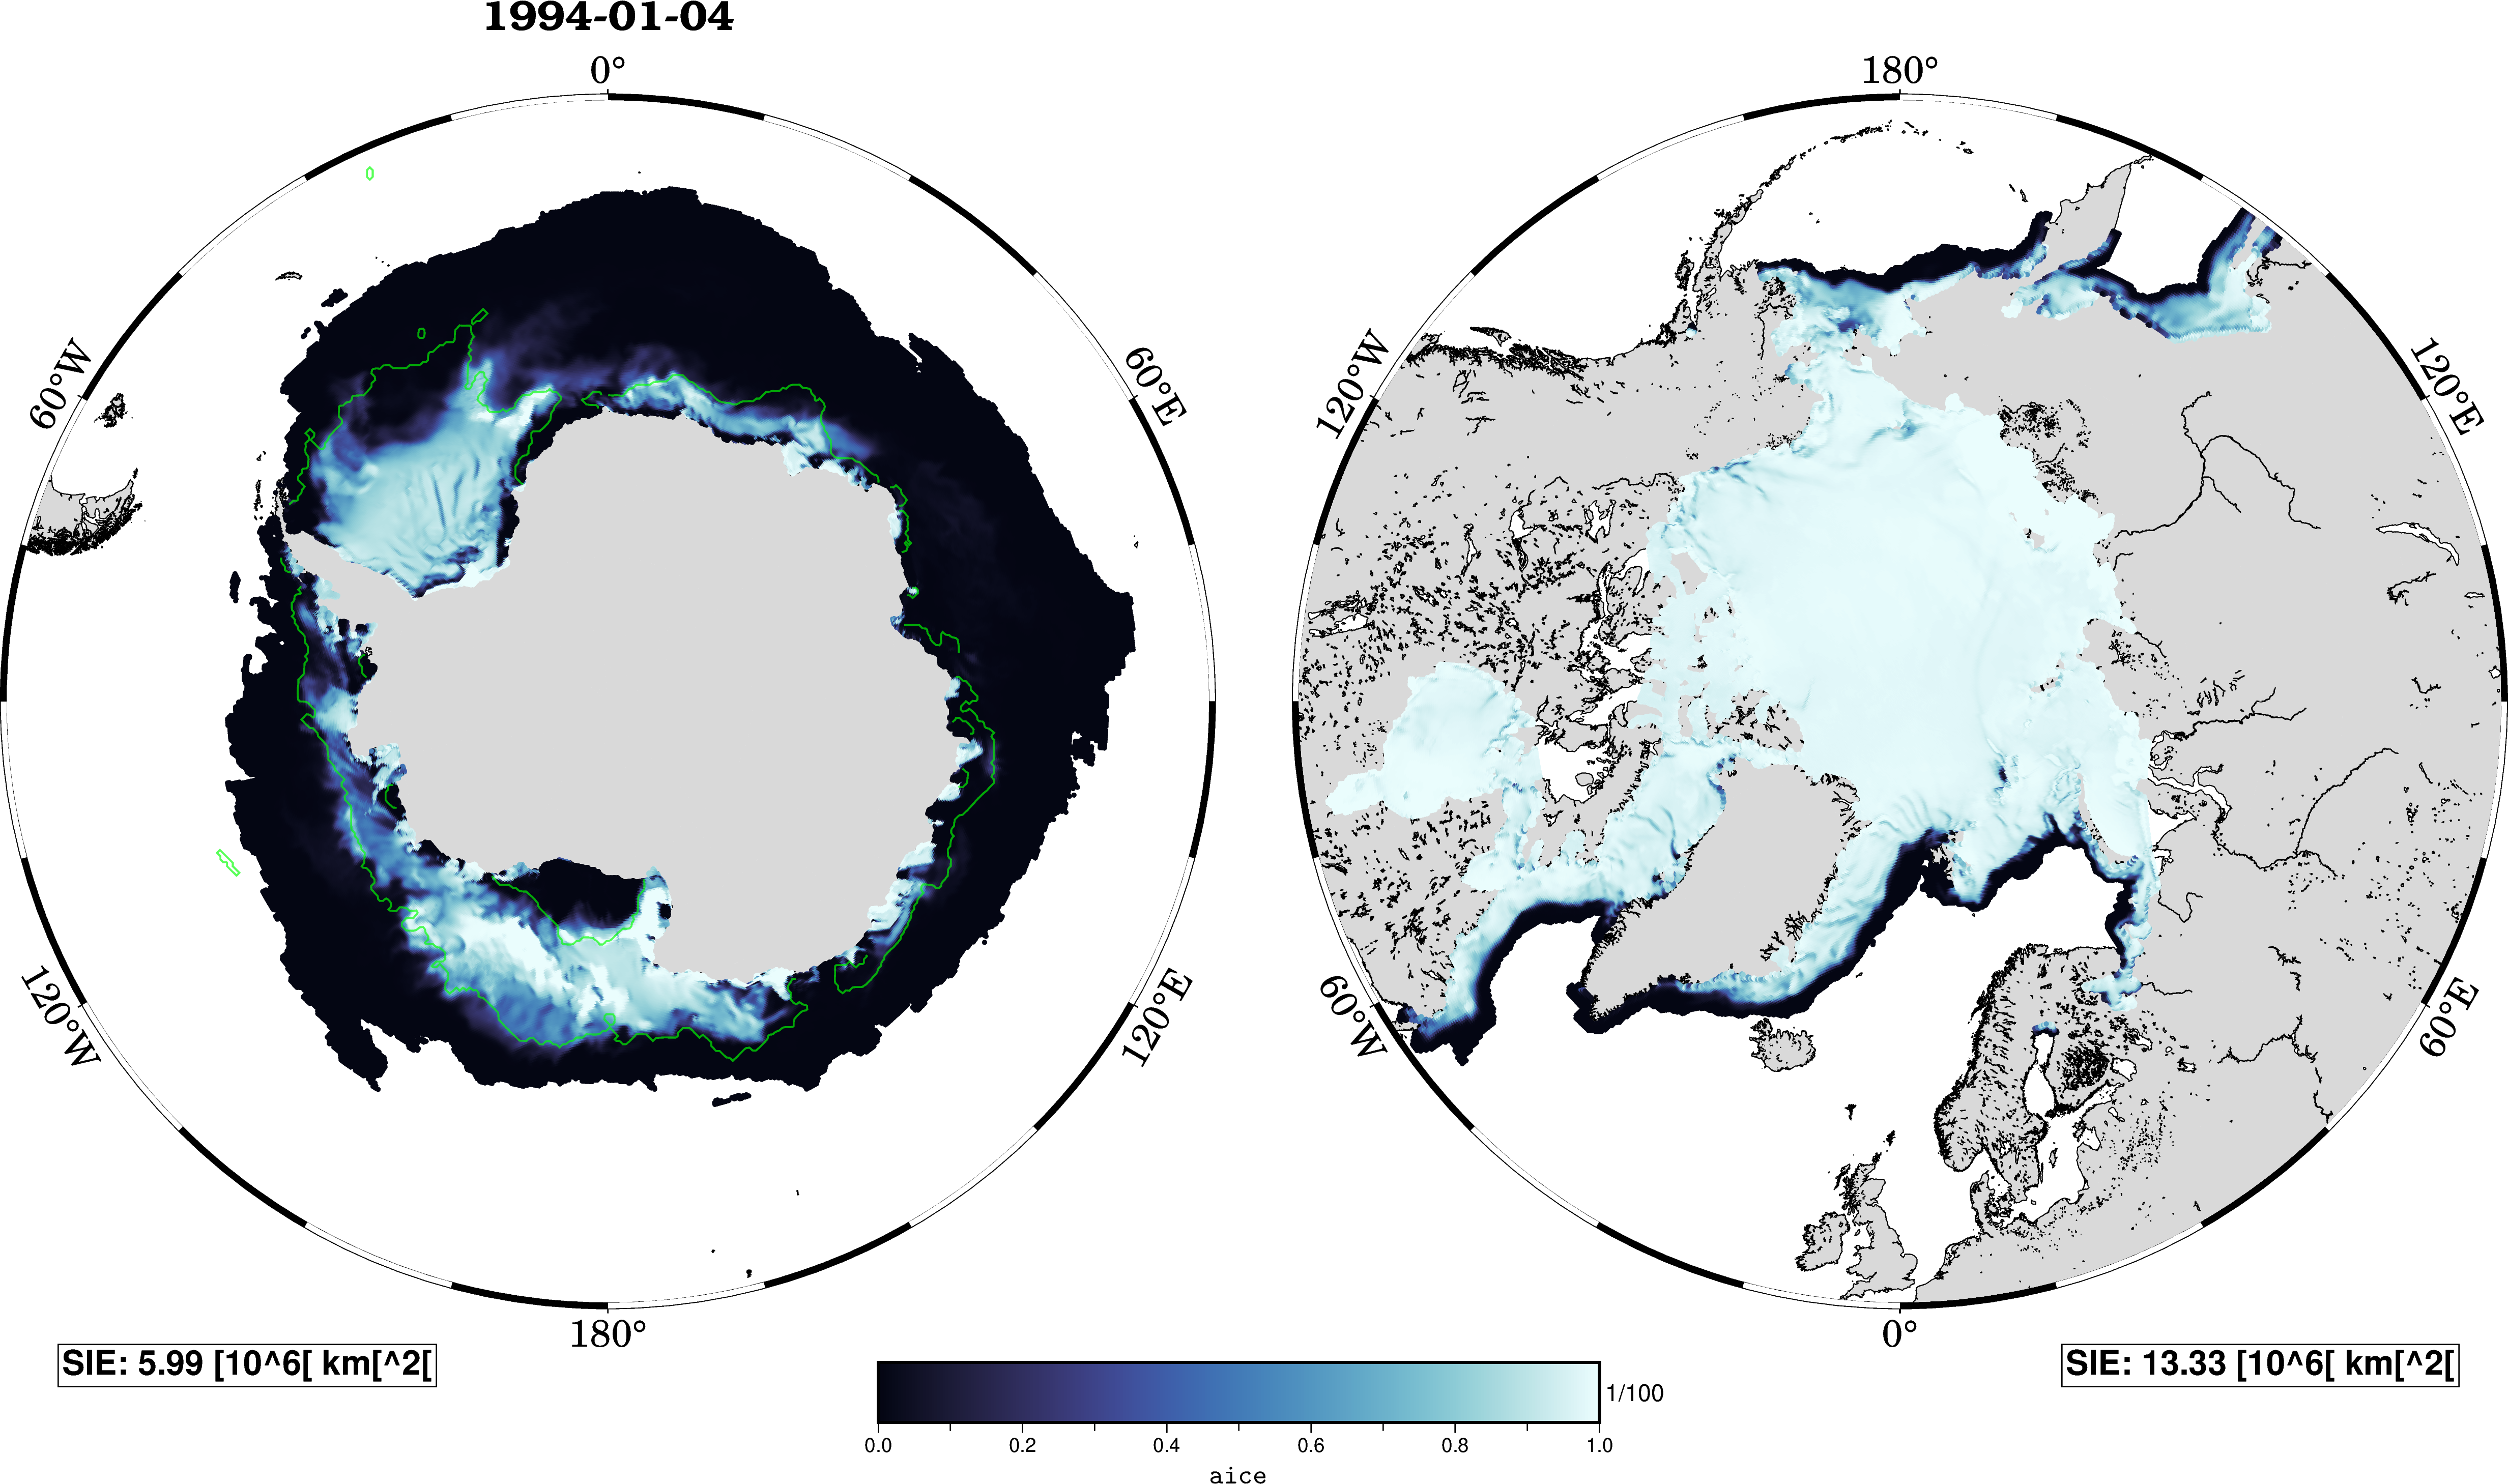

In [6]:
Path(tb.paths.output_dir,"aice").mkdir(parents=True, exist_ok=True)
fig = tb.plot_aice_day(date_str, add_nsidc_south=True, add_nsidc_north=False, show=True, output_path=tb.paths.output_dir / "aice" / f"{date_str}.png")

## Daily thickness figure from model `hi`

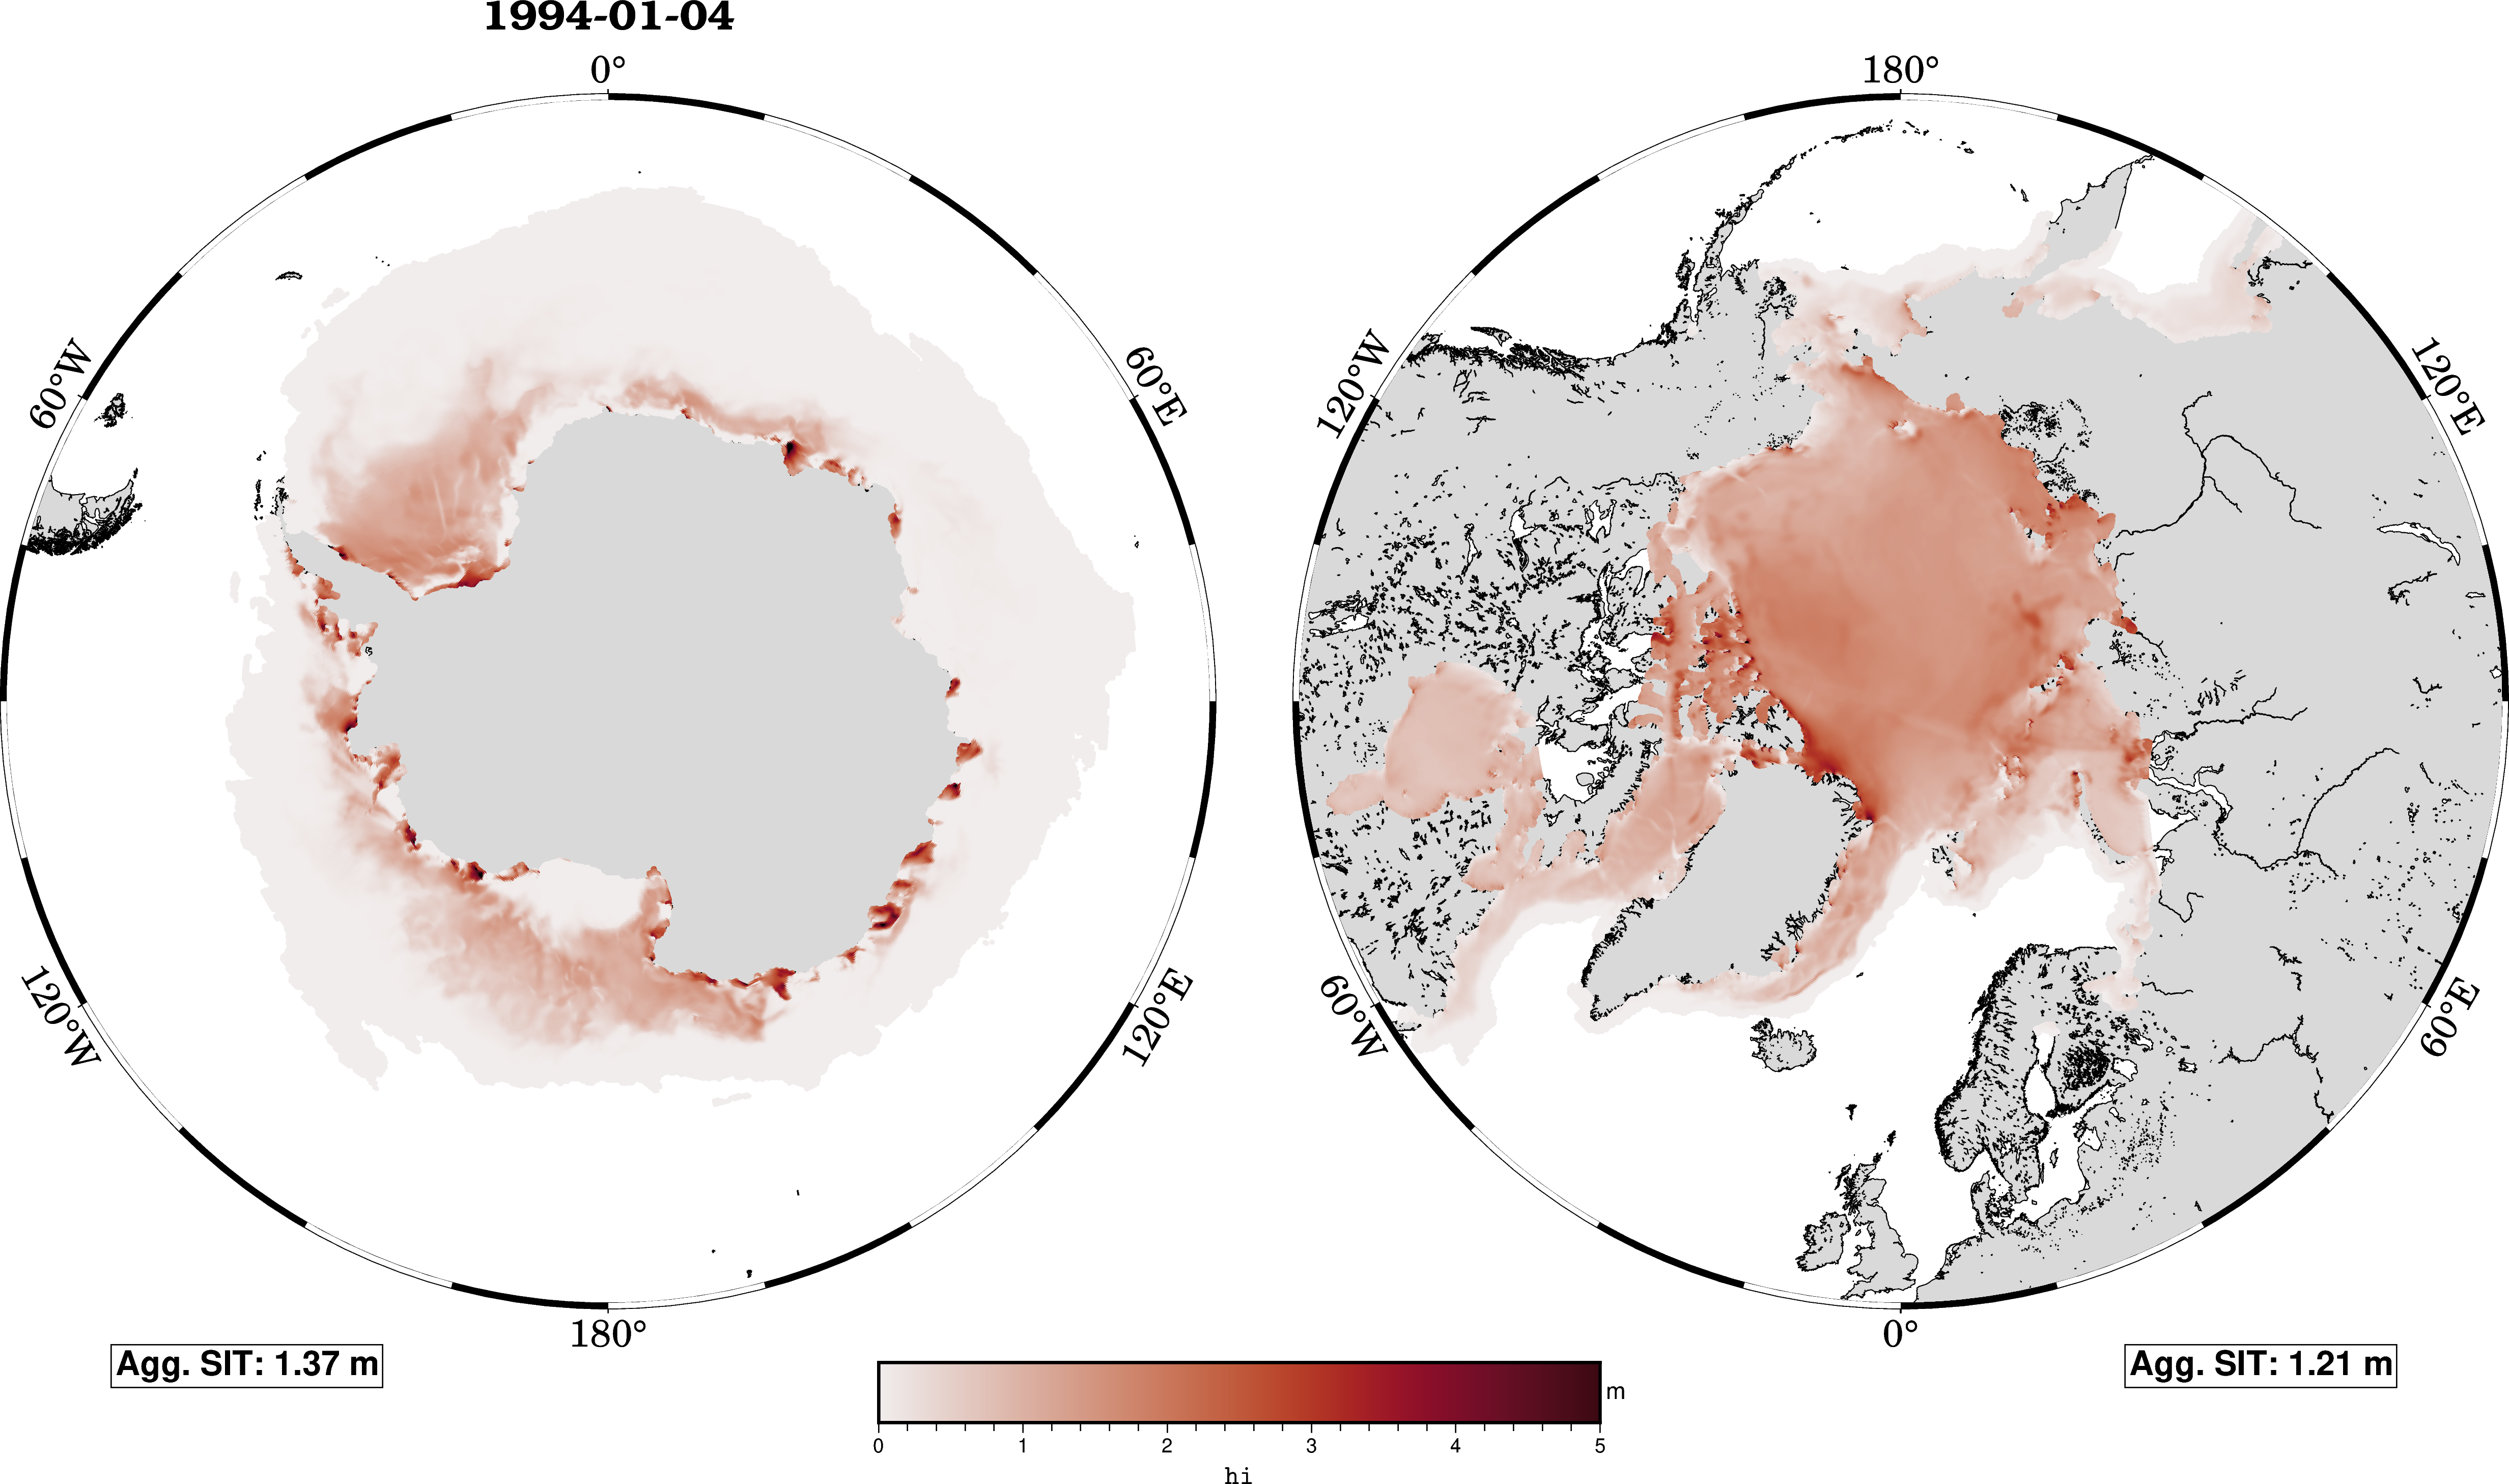

In [7]:
Path(tb.paths.output_dir,"hi").mkdir(parents=True, exist_ok=True)
fig = tb.plot_hi_day(date_str, show=True, output_path=tb.paths.output_dir / "hi" / f"{date_str}.png")

## Optional: add a SIA timeseries inset

This builds simple daily time series from CICE and NSIDC and draws an inset on the `aice` figure.

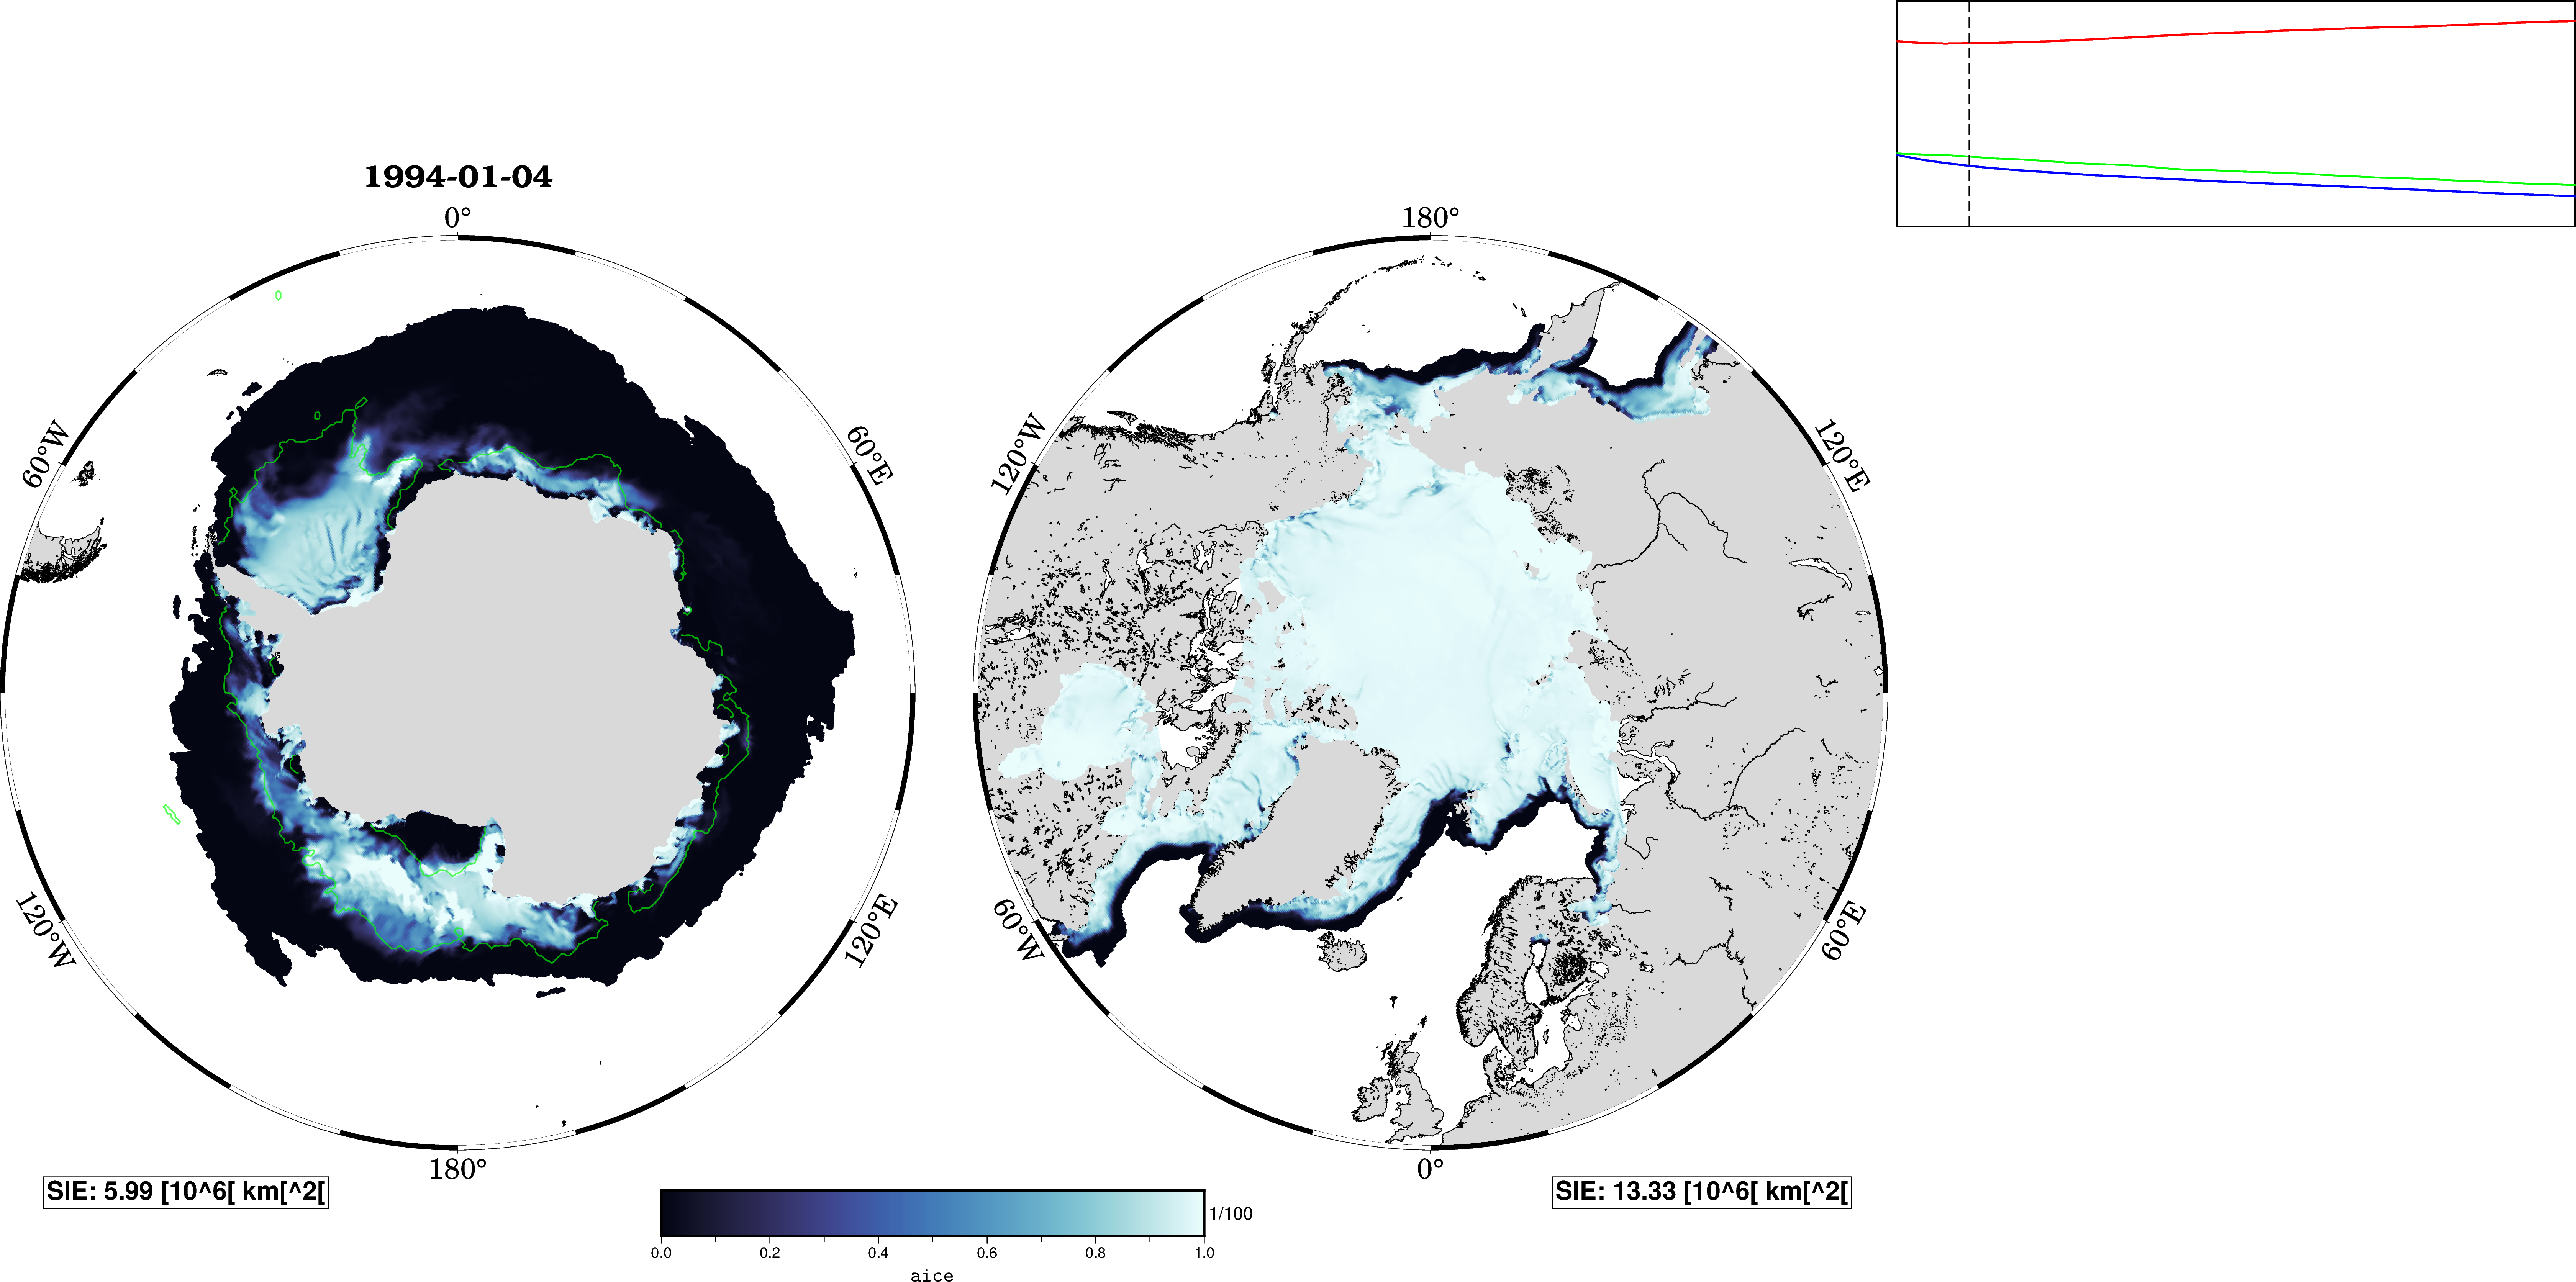

In [8]:
fig = tb.plot_aice_day(date_str,
                       add_nsidc_south    = True,
                       add_sia_timeseries = True,
                       ts_start           = "1994-01-01",
                       ts_end             = "1994-01-29",
                       show               = True)

## Optional: create an animation

This will render daily frames and combine them into a GIF or MP4.

In [10]:
gif_path = tb.create_animation(dt0_str            = "1994-01-01",
                               dtN_str            = "1994-01-11",
                               variable           = "aice",
                               add_sia_timeseries = False,
                               fps                = 4,
                               codec              = "gif")
print(gif_path)

ValueError: all input arrays must have the same shape

In [ ]:
from IPython.display import Image, display
display(Image(filename=f"{gif_path}"))

## Notes

- The class assumes direct `iceh.*.nc` access rather than a prebuilt Zarr archive.
- The corrected CICE date is computed by subtracting one day from the in-file time coordinate.
- NSIDC daily metrics use the official NSIDC0771 cell-area files for the chosen hemisphere.
- The northern NSIDC path is already wired into the class, so once the files are in place the same notebook cells can be used for NH comparisons.